In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cpu


In [12]:
batch_size = 128
image_size = 28
channels = 1
latent_dim = 100
epochs = 15
lr = 0.0002

In [13]:
os.makedirs("generated_fashion_images", exist_ok=True)


In [14]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True
)

In [15]:
class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(latent_dim, 256),
            nn.ReLU(True),

            nn.Linear(256, 512),
            nn.ReLU(True),

            nn.Linear(512, 1024),
            nn.ReLU(True),

            nn.Linear(1024, image_size * image_size),
            nn.Tanh()
        )

    def forward(self, z):

        img = self.model(z)
        img = img.view(z.size(0), 1, image_size, image_size)

        return img

In [16]:
class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(image_size * image_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):

        img_flat = img.view(img.size(0), -1)

        validity = self.model(img_flat)

        return validity

In [17]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=lr)
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr)

In [18]:
for epoch in range(epochs):

    for batch_idx, (real_images, _) in enumerate(dataloader):

        real_images = real_images.to(device)

        current_batch_size = real_images.size(0)

        # ====================================================
        # Labels
        # ====================================================

        real_labels = torch.ones(current_batch_size, 1).to(device)
        fake_labels = torch.zeros(current_batch_size, 1).to(device)

        # ====================================================
        # Train Generator
        # ====================================================

        optimizer_G.zero_grad()

        noise = torch.randn(current_batch_size, latent_dim).to(device)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        g_loss = criterion(outputs, real_labels)

        g_loss.backward()

        optimizer_G.step()

        # ====================================================
        # Train Discriminator
        # ====================================================

        optimizer_D.zero_grad()

        real_outputs = discriminator(real_images)
        real_loss = criterion(real_outputs, real_labels)

        fake_outputs = discriminator(fake_images.detach())
        fake_loss = criterion(fake_outputs, fake_labels)

        d_loss = (real_loss + fake_loss) / 2

        d_loss.backward()

        optimizer_D.step()

        # ====================================================
        # Print Progress
        # ====================================================

        if batch_idx % 100 == 0:

            print(
                f"Epoch [{epoch+1}/{epochs}] "
                f"Batch [{batch_idx}/{len(dataloader)}] "
                f"D Loss: {d_loss.item():.4f} "
                f"G Loss: {g_loss.item():.4f}"
            )

    # ========================================================
    # Save Images Every Epoch
    # ========================================================

    save_image(
        fake_images[:25],
        f"generated_fashion_images/epoch_{epoch+1}.png",
        nrow=5,
        normalize=True
    )

Epoch [1/15] Batch [0/469] D Loss: 0.7024 G Loss: 0.6977
Epoch [1/15] Batch [100/469] D Loss: 0.1663 G Loss: 1.6540
Epoch [1/15] Batch [200/469] D Loss: 0.0983 G Loss: 3.4370
Epoch [1/15] Batch [300/469] D Loss: 0.0603 G Loss: 3.6720
Epoch [1/15] Batch [400/469] D Loss: 0.0083 G Loss: 4.1570
Epoch [2/15] Batch [0/469] D Loss: 0.1577 G Loss: 2.4182
Epoch [2/15] Batch [100/469] D Loss: 0.1000 G Loss: 3.1066
Epoch [2/15] Batch [200/469] D Loss: 0.1277 G Loss: 1.9820
Epoch [2/15] Batch [300/469] D Loss: 0.0855 G Loss: 3.3580
Epoch [2/15] Batch [400/469] D Loss: 0.1002 G Loss: 2.9782
Epoch [3/15] Batch [0/469] D Loss: 0.0043 G Loss: 4.9717
Epoch [3/15] Batch [100/469] D Loss: 0.0914 G Loss: 2.8429
Epoch [3/15] Batch [200/469] D Loss: 0.0148 G Loss: 3.6775
Epoch [3/15] Batch [300/469] D Loss: 0.3723 G Loss: 3.0380
Epoch [3/15] Batch [400/469] D Loss: 0.0774 G Loss: 4.2255
Epoch [4/15] Batch [0/469] D Loss: 0.0686 G Loss: 3.8570
Epoch [4/15] Batch [100/469] D Loss: 0.1374 G Loss: 4.1358
Epoch

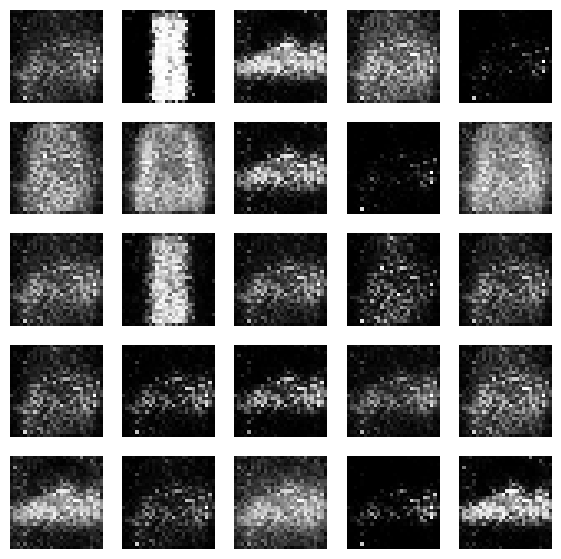

In [19]:
noise = torch.randn(25, latent_dim).to(device)

generated_images = generator(noise).detach().cpu()

# ============================================================
# Display Images
# ============================================================

fig, axes = plt.subplots(5, 5, figsize=(7, 7))

index = 0

for i in range(5):
    for j in range(5):

        axes[i, j].imshow(
            generated_images[index][0],
            cmap="gray"
        )

        axes[i, j].axis("off")

        index += 1

plt.show()